# 03 — Audio Feature Extraction & 5-Class Emotion Classification

## Research Question
**Can we classify speech emotion (angry / happy / sad / neutral / frustrated) from audio features alone?**

## Approach
Every audio recording is a waveform — a sequence of numbers representing air pressure over time.
We extract **numerical features** from each waveform:

| Feature | What it captures | # values |
|---------|-----------------|---------|
| MFCCs (mean+std) | Vocal tract shape | 26 (13x2) |
| Pitch F0 (mean+std) | Voice pitch | 2 |
| RMS (mean+std) | Loudness | 2 |
| Spectral Centroid (mean+std) | Brightness | 2 |
| Zero Crossing Rate (mean+std) | Noisiness | 2 |
| **Total** | | **34 features** |

These 34 numbers become one row in our feature matrix.
We train a **Random Forest classifier** and evaluate with **LOSO cross-validation**.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import librosa, librosa.display
import seaborn as sns
from datasets import load_dataset
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({"figure.dpi":120,"font.family":"sans-serif"})
FIG_DIR = Path("../reports/figures"); FIG_DIR.mkdir(parents=True, exist_ok=True)

# 5-class setup — frustrated is included
TARGET_EMOTIONS = ["angry", "happy", "sad", "neutral", "frustrated"]
EMO_COLORS = {
    "angry":     "#e74c3c",
    "happy":     "#f39c12",
    "neutral":   "#3498db",
    "sad":       "#9b59b6",
    "frustrated":"#c0392b",
}

print("Loading IEMOCAP dataset...")
ds = load_dataset("AbstractTTS/IEMOCAP", split="train")
total_target = sum(1 for x in ds if x.get("major_emotion","") in TARGET_EMOTIONS)
print(f"Total recordings in target classes: {total_target:,}")
print("Ready")

Loading IEMOCAP dataset...
Total recordings in target classes: 7,818
Ready


## 1. Class Distribution
How many samples do we have per emotion? Class imbalance affects model performance.

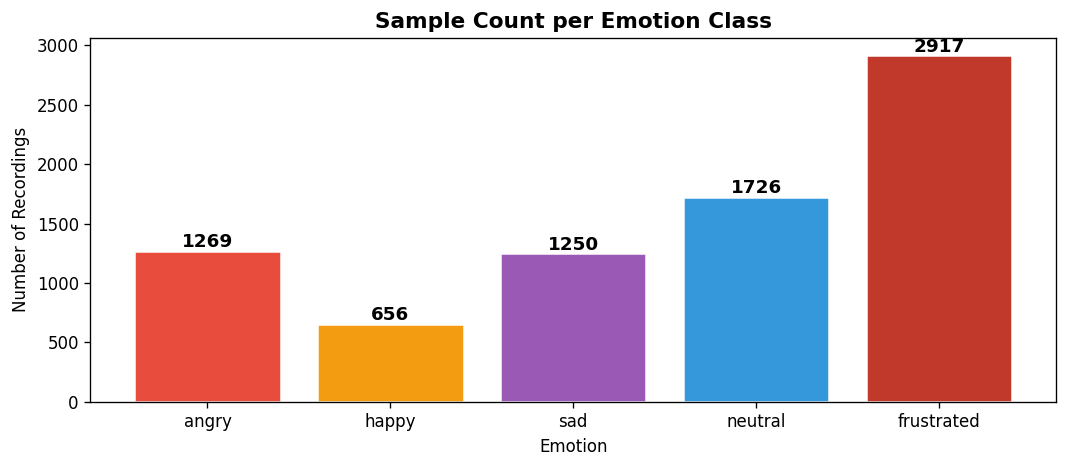

In [2]:
counts = {e: 0 for e in TARGET_EMOTIONS}
for item in ds:
    emo = item.get("major_emotion", "")
    if emo in TARGET_EMOTIONS:
        counts[emo] += 1

plt.figure(figsize=(9, 4))
bars = plt.bar(counts.keys(), counts.values(),
               color=[EMO_COLORS[e] for e in counts], edgecolor="white", linewidth=1.5)
plt.title("Sample Count per Emotion Class", fontweight="bold", fontsize=13)
plt.ylabel("Number of Recordings")
plt.xlabel("Emotion")
for bar, val in zip(bars, counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             str(val), ha="center", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR/"F0_class_distribution.png", bbox_inches="tight"); plt.show()

## 2. Waveform & Mel-Spectrogram Comparison
One representative sample per emotion — shows the raw signal and its frequency content.

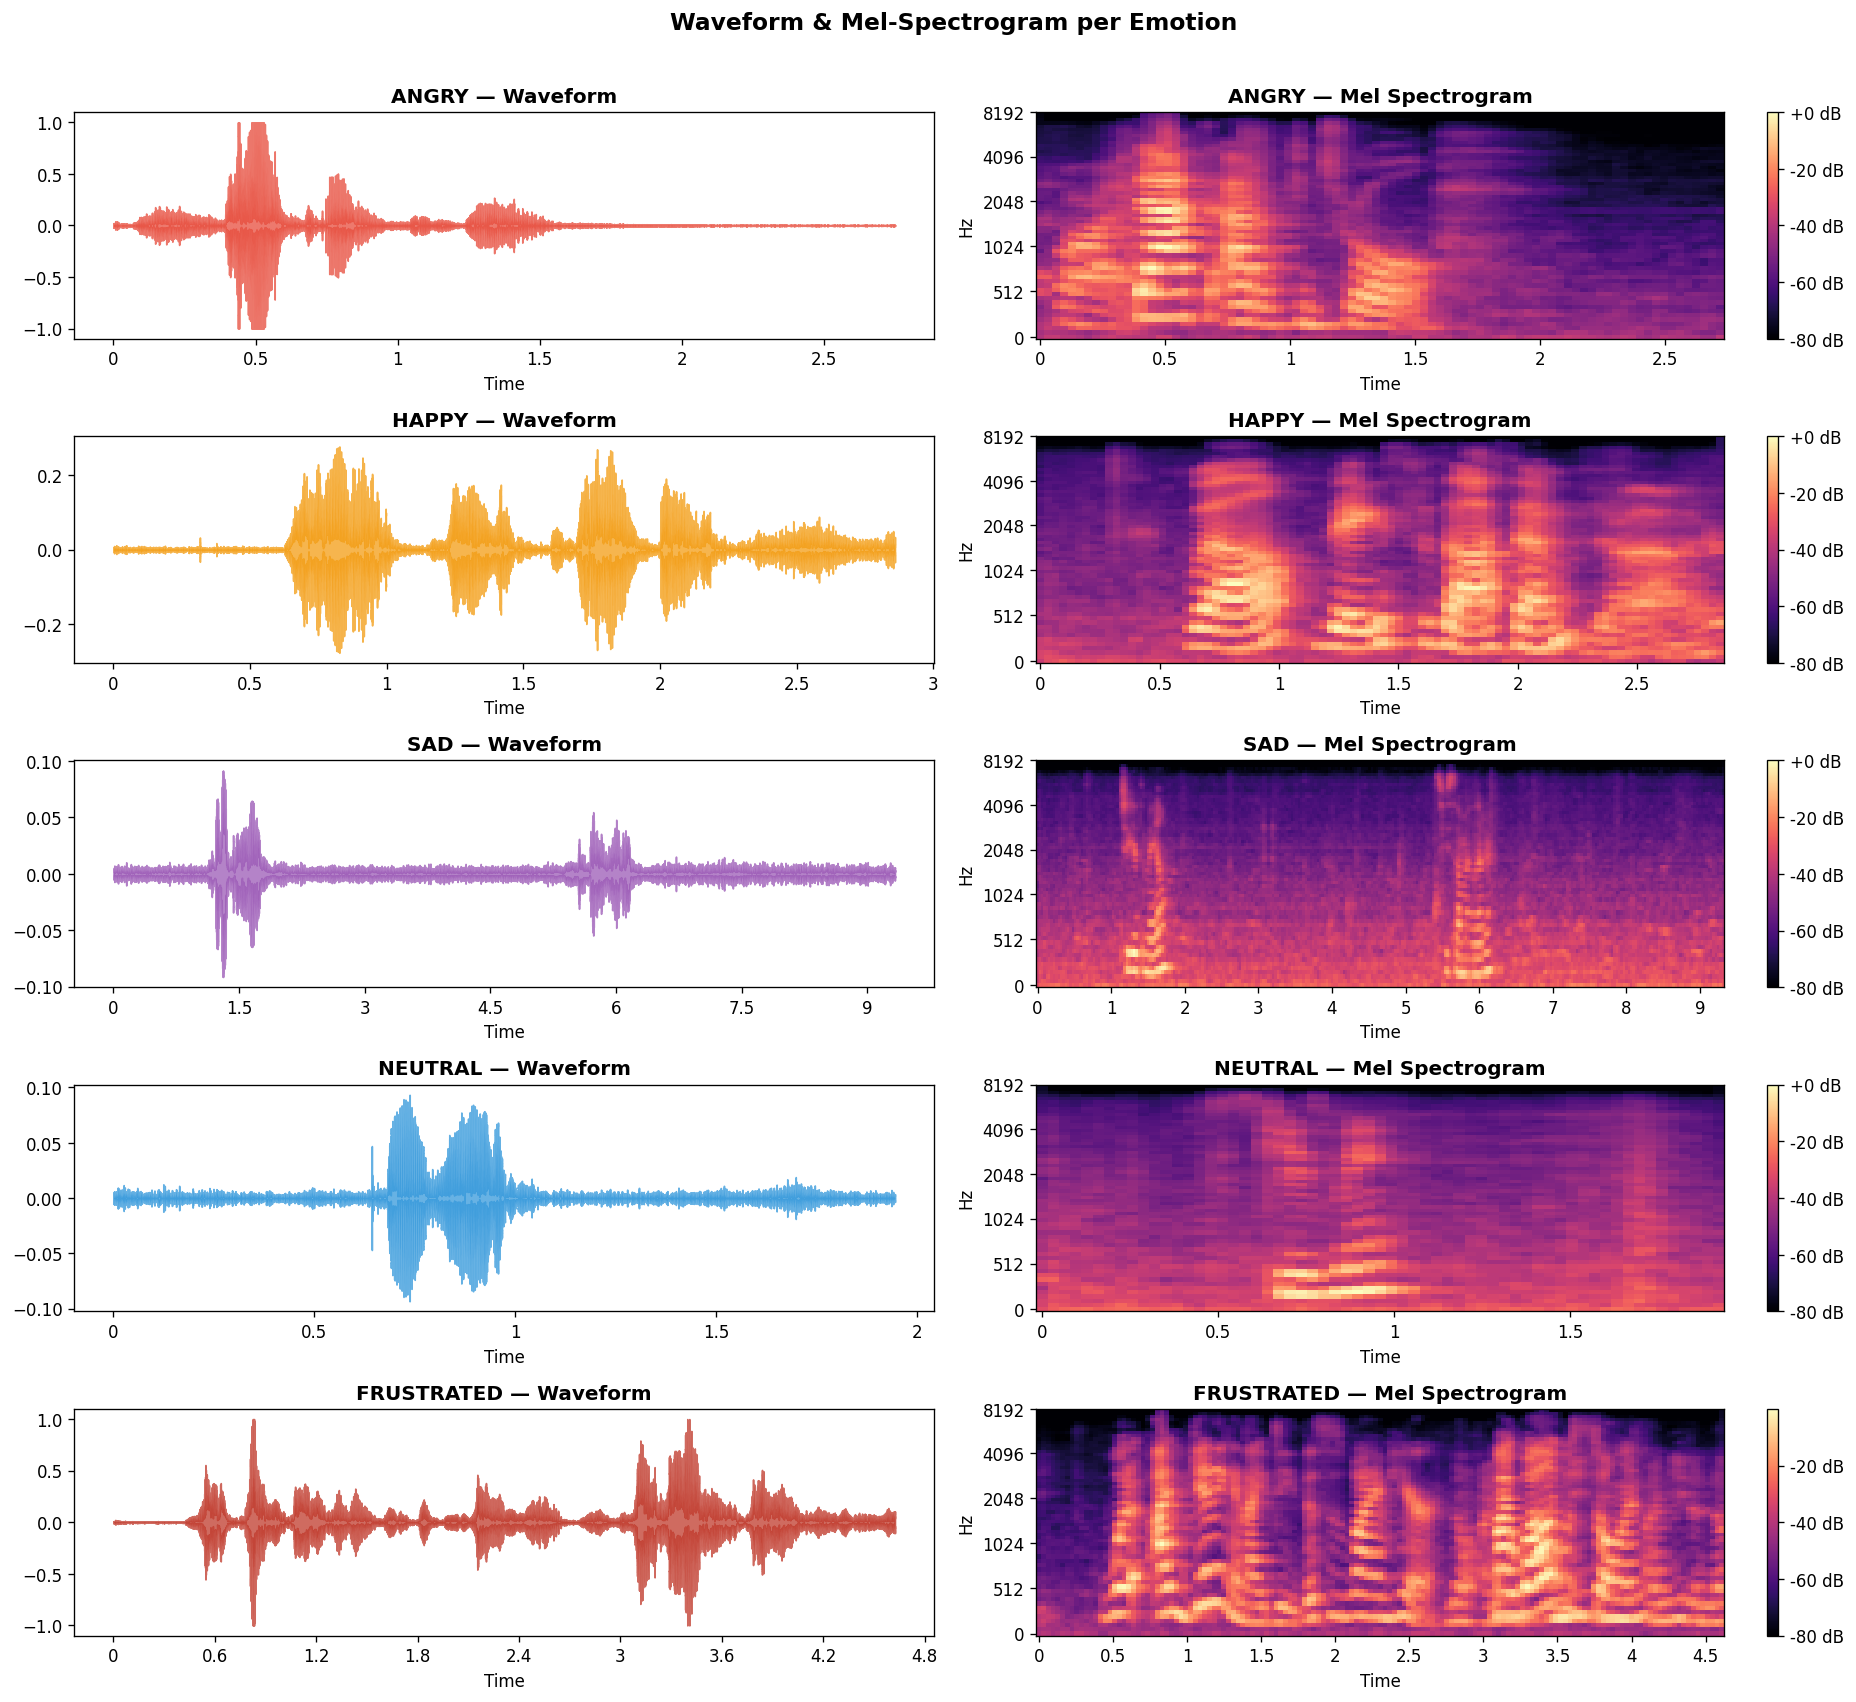

In [3]:
samples_by_emo = {}
for item in ds:
    emo = item.get("major_emotion", "")
    if emo in TARGET_EMOTIONS and emo not in samples_by_emo:
        samples_by_emo[emo] = item
    if len(samples_by_emo) == len(TARGET_EMOTIONS): break

fig, axes = plt.subplots(len(TARGET_EMOTIONS), 2, figsize=(16, 14))
for row, emo in enumerate(TARGET_EMOTIONS):
    item = samples_by_emo[emo]
    y_ = np.array(item["audio"]["array"], dtype=np.float32)
    sr_ = item["audio"]["sampling_rate"]
    color = EMO_COLORS[emo]

    librosa.display.waveshow(y_, sr=sr_, ax=axes[row,0], color=color, alpha=0.75)
    axes[row,0].set_title(f"{emo.upper()} — Waveform", fontweight="bold")

    S = librosa.feature.melspectrogram(y=y_, sr=sr_, n_mels=64)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr_, x_axis="time", y_axis="mel",
                                   ax=axes[row,1], cmap="magma")
    axes[row,1].set_title(f"{emo.upper()} — Mel Spectrogram", fontweight="bold")
    fig.colorbar(img, ax=axes[row,1], format="%+2.0f dB")

plt.suptitle("Waveform & Mel-Spectrogram per Emotion", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR/"F1_waveform_spectrogram.png", bbox_inches="tight"); plt.show()

## 3. Feature Extraction Function
34 acoustic features extracted per recording (mean + std captures overall value and variability).

In [4]:
def extract_features(y: np.ndarray, sr: int) -> dict:
    y = y.astype(np.float32)
    feats = {}
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    for i in range(13):
        feats[f"mfcc_{i+1}_mean"] = float(np.mean(mfcc[i]))
        feats[f"mfcc_{i+1}_std"]  = float(np.std(mfcc[i]))

    f0, _, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    f0c = f0[~np.isnan(f0)] if f0 is not None else np.array([0.0])
    feats["pitch_mean"] = float(np.mean(f0c)) if len(f0c) > 0 else 0.0
    feats["pitch_std"]  = float(np.std(f0c))  if len(f0c) > 0 else 0.0

    rms = librosa.feature.rms(y=y)[0]
    feats["rms_mean"] = float(np.mean(rms)); feats["rms_std"] = float(np.std(rms))

    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    feats["sc_mean"] = float(np.mean(sc)); feats["sc_std"] = float(np.std(sc))

    zcr = librosa.feature.zero_crossing_rate(y)[0]
    feats["zcr_mean"] = float(np.mean(zcr)); feats["zcr_std"] = float(np.std(zcr))
    return feats

test = extract_features(np.array(ds[0]["audio"]["array"]), ds[0]["audio"]["sampling_rate"])
print(f"Features per recording: {len(test)}")
print("Feature extraction ready")

Features per recording: 34
Feature extraction ready


## 4. Extract Features from All Recordings
Processes every valid recording. Takes ~10-15 min due to pitch extraction.

In [5]:
rows, errors = [], 0
print(f"Extracting features...")
for i, item in enumerate(ds):
    emo = item.get("major_emotion", "")
    if emo not in TARGET_EMOTIONS:
        continue
    try:
        y_  = np.array(item["audio"]["array"], dtype=np.float32)
        sr_ = item["audio"]["sampling_rate"]
        if len(y_) < sr_ * 0.3:
            continue
        feats = extract_features(y_, sr_)
        feats["emotion"] = emo
        fname = item.get("file","")
        feats["session"] = fname.split("/")[0] if "/" in fname else fname[:5]
        rows.append(feats)
    except Exception:
        errors += 1
    if (i+1) % 500 == 0:
        print(f"  {i+1:,} processed | valid: {len(rows):,}")

df = pd.DataFrame(rows)
print(f"Done. Valid: {len(df):,} | Errors: {errors}")
print("\nClass distribution:")
print(df["emotion"].value_counts().to_string())
df.to_csv("../data/audio_features.csv", index=False)
print("\nSaved: data/audio_features.csv")

Extracting features...
  500 processed | valid: 444
  2,000 processed | valid: 1,611
  2,500 processed | valid: 1,982
  3,500 processed | valid: 2,751
  4,000 processed | valid: 3,124
  4,500 processed | valid: 3,540
  5,000 processed | valid: 3,979
  6,000 processed | valid: 4,755
  6,500 processed | valid: 5,108
  8,500 processed | valid: 6,610
  9,000 processed | valid: 6,997
  9,500 processed | valid: 7,403
  10,000 processed | valid: 7,779
Done. Valid: 7,818 | Errors: 0

Class distribution:
emotion
frustrated    2917
neutral       1726
angry         1269
sad           1250
happy          656

Saved: data/audio_features.csv


In [6]:
# ── Load CSV and fix legacy 3-class sentiment mapping ─────────────────────────
import pandas as pd

CSV_PATH = "../data/audio_features.csv"
df = pd.read_csv(CSV_PATH)

print(f"CSV loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"Columns: {df.columns.tolist()}")

# Drop old sentiment column if present
if 'sentiment' in df.columns:
    df = df.drop(columns=['sentiment'])
    print("Dropped legacy 'sentiment' column.")

# Keep only the 5 target emotions
df = df[df['emotion'].isin(TARGET_EMOTIONS)].copy()
df = df.dropna(subset=['emotion'])

print(f"\nAfter filtering to 5 emotions: {len(df):,} rows")
print("\nEmotion counts:")
print(df['emotion'].value_counts().to_string())
print(f"\nAll 5 emotions present: {sorted(df['emotion'].unique()) == sorted(TARGET_EMOTIONS)}")

CSV loaded: 7,818 rows, 36 columns
Columns: ['mfcc_1_mean', 'mfcc_1_std', 'mfcc_2_mean', 'mfcc_2_std', 'mfcc_3_mean', 'mfcc_3_std', 'mfcc_4_mean', 'mfcc_4_std', 'mfcc_5_mean', 'mfcc_5_std', 'mfcc_6_mean', 'mfcc_6_std', 'mfcc_7_mean', 'mfcc_7_std', 'mfcc_8_mean', 'mfcc_8_std', 'mfcc_9_mean', 'mfcc_9_std', 'mfcc_10_mean', 'mfcc_10_std', 'mfcc_11_mean', 'mfcc_11_std', 'mfcc_12_mean', 'mfcc_12_std', 'mfcc_13_mean', 'mfcc_13_std', 'pitch_mean', 'pitch_std', 'rms_mean', 'rms_std', 'sc_mean', 'sc_std', 'zcr_mean', 'zcr_std', 'emotion', 'session']

After filtering to 5 emotions: 7,818 rows

Emotion counts:
emotion
frustrated    2917
neutral       1726
angry         1269
sad           1250
happy          656

All 5 emotions present: True


## 5. Feature Distributions by Emotion
KDE plots for the 6 most informative features. Separated curves = discriminative feature.

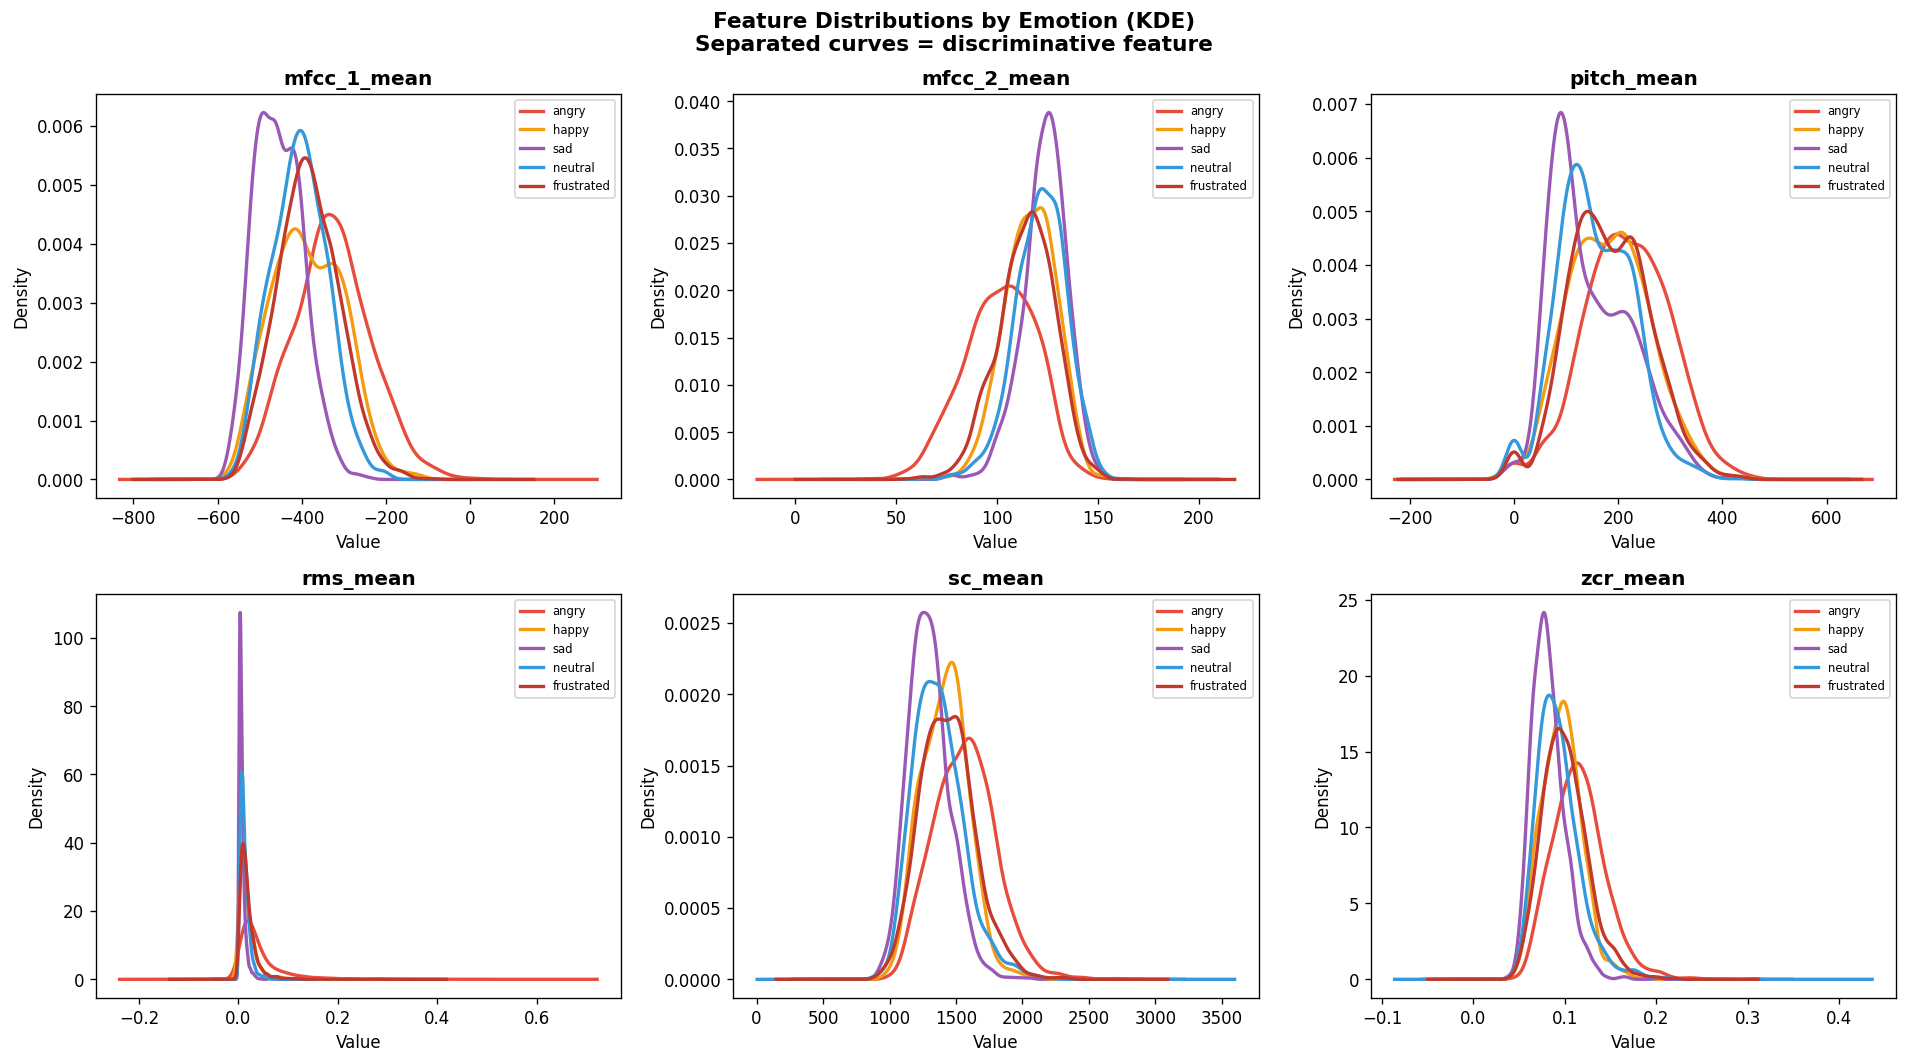

Mean feature values by emotion:
            mfcc_1_mean  mfcc_2_mean  pitch_mean  rms_mean   sc_mean  zcr_mean
emotion                                                                       
angry          -326.851      101.580     217.195     0.042  1567.549     0.116
frustrated     -383.536      114.358     183.091     0.019  1438.631     0.100
happy          -385.047      116.442     181.834     0.018  1418.755     0.097
neutral        -404.375      121.527     156.136     0.013  1372.167     0.093
sad            -454.633      123.511     147.388     0.007  1298.735     0.082


In [7]:
show_feats = ["mfcc_1_mean","mfcc_2_mean","pitch_mean","rms_mean","sc_mean","zcr_mean"]
show_feats = [f for f in show_feats if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, show_feats):
    for emo in TARGET_EMOTIONS:
        data = df[df["emotion"]==emo][feat].dropna()
        data.plot(kind="kde", ax=ax, label=emo, color=EMO_COLORS[emo], linewidth=2)
    ax.set_title(feat, fontweight="bold"); ax.set_xlabel("Value"); ax.legend(fontsize=7)

plt.suptitle("Feature Distributions by Emotion (KDE)\nSeparated curves = discriminative feature",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"F2_feature_distributions.png", bbox_inches="tight"); plt.show()

print("Mean feature values by emotion:")
print(df.groupby("emotion")[show_feats].mean().round(3).to_string())

## 6. Boxplots — Feature Spread per Emotion
Shows median and inter-quartile range; helps spot outliers.

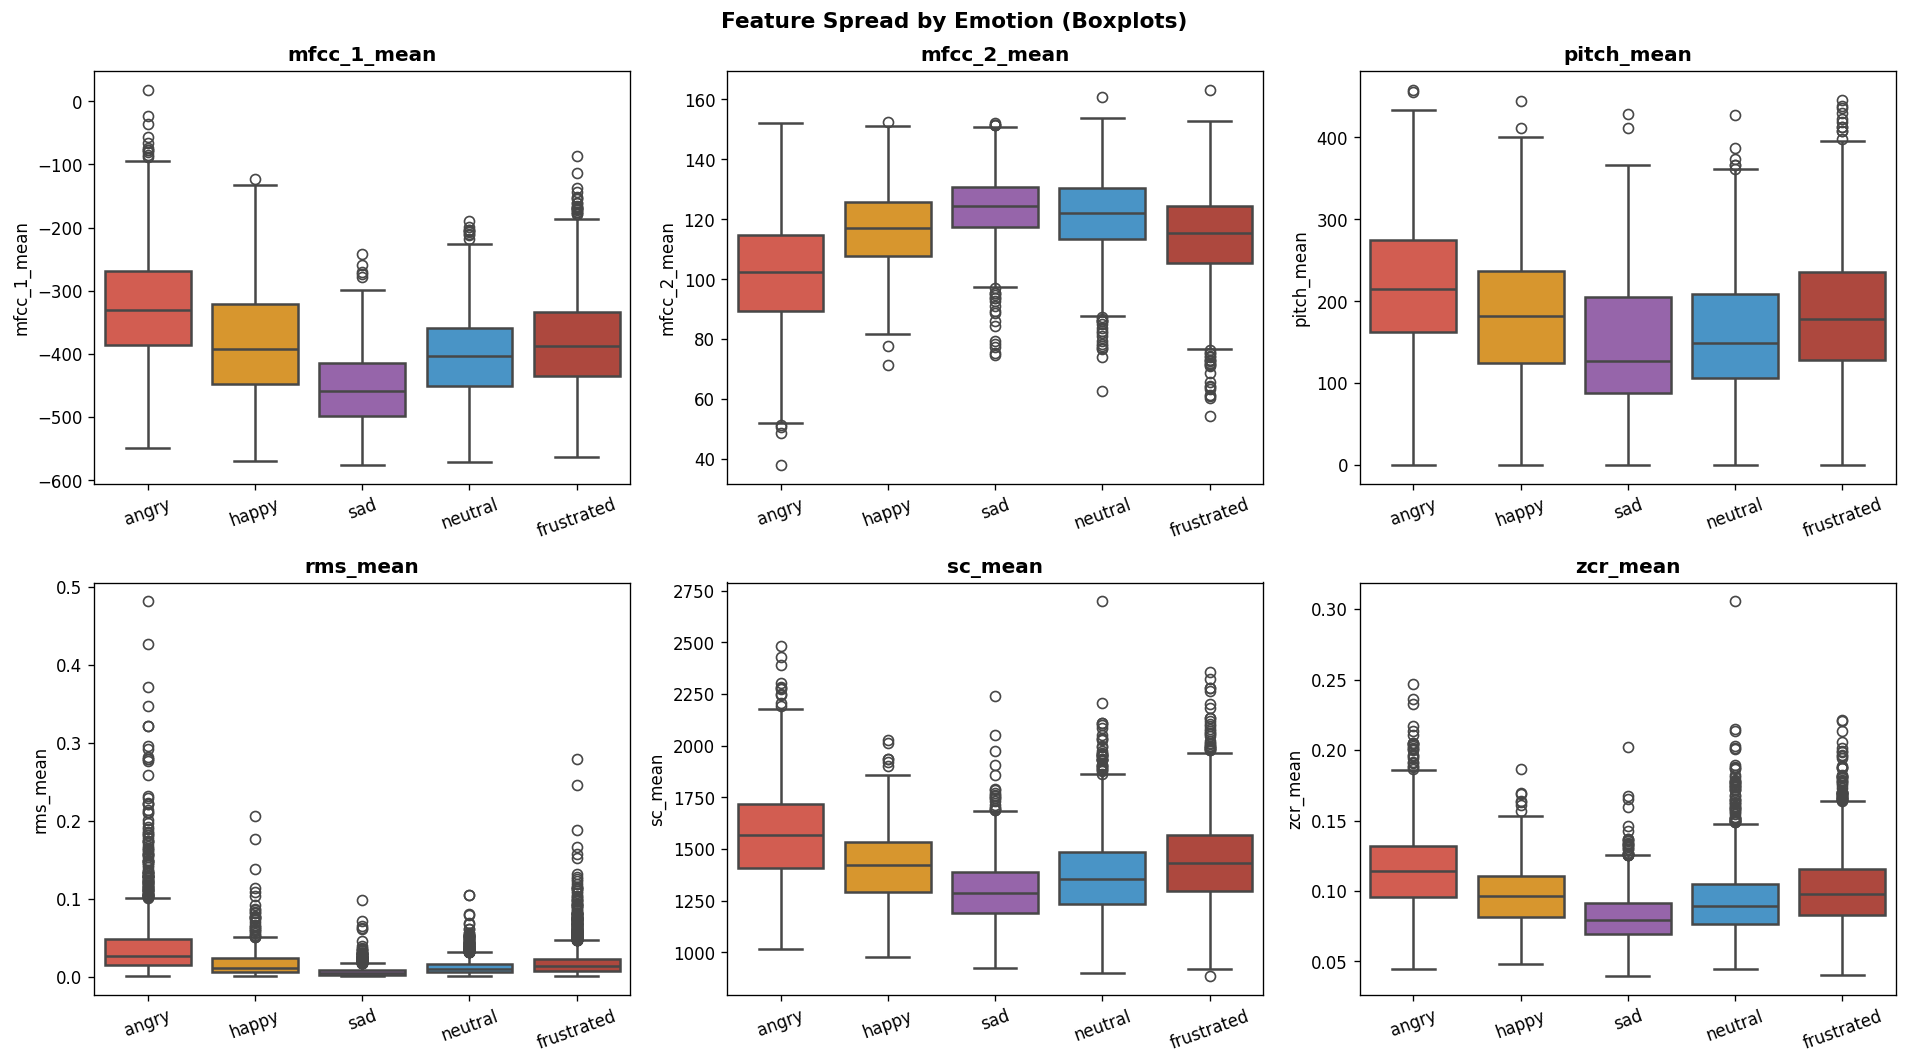

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feat in zip(axes.flat, show_feats):
    sns.boxplot(x="emotion", y=feat, data=df, ax=ax,
                palette=EMO_COLORS, order=TARGET_EMOTIONS, linewidth=1.5)
    ax.set_title(feat, fontweight="bold"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)

plt.suptitle("Feature Spread by Emotion (Boxplots)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR/"F3_boxplots.png", bbox_inches="tight"); plt.show()

## 7. Correlation Heatmap
Pearson correlation between features. High correlation = possible redundancy.

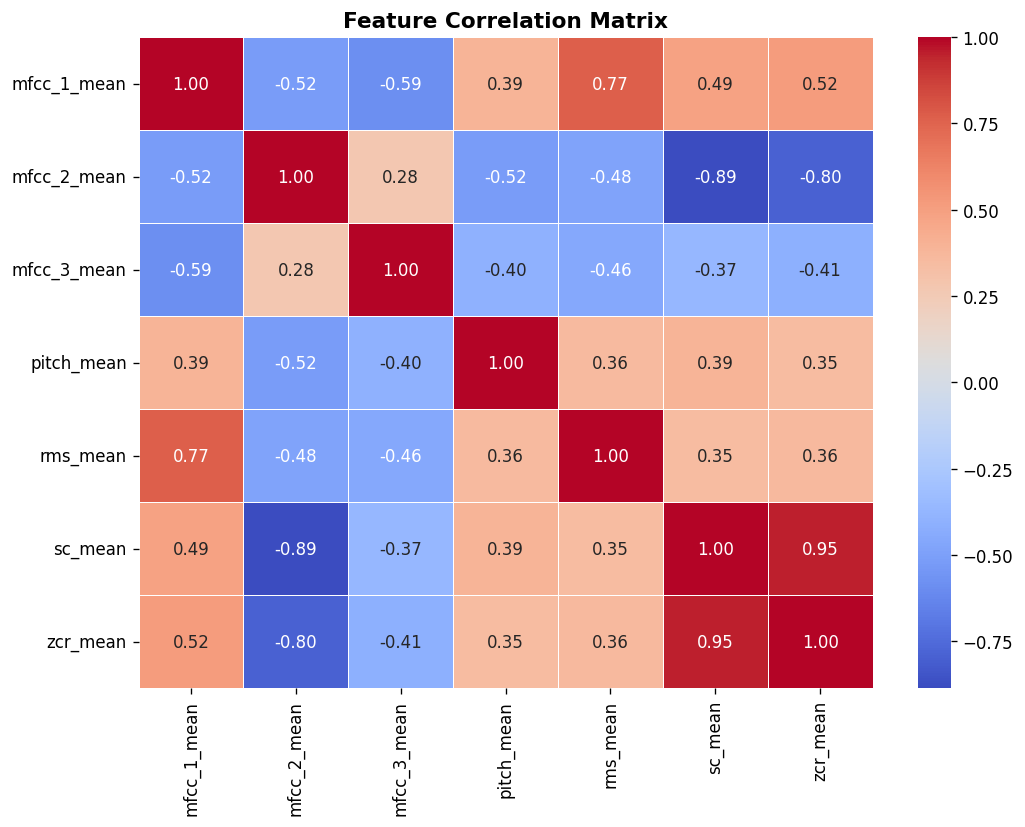

In [9]:
non_mfcc = [c for c in df.columns if "mean" in c and "mfcc" not in c]
selected = ["mfcc_1_mean","mfcc_2_mean","mfcc_3_mean"] + non_mfcc
selected = [c for c in selected if c in df.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(df[selected].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR/"F4_correlation.png", bbox_inches="tight"); plt.show()

## 8. Model Training — Random Forest with LOSO CV

**Why LOSO (Leave-One-Session-Out)?**
IEMOCAP has 5 sessions with different speakers.
Train on 4 sessions → test on 1. Prevents speaker identity leakage.

**Metric: UAR (Unweighted Average Recall)**
Mean of per-class recall. Random baseline = 0.20 for 5 classes.

In [10]:
feature_cols = [c for c in df.columns if c not in ["emotion","session"]]
X = df[feature_cols].fillna(0).values
y_emo = df["emotion"].values
df["session_id"] = df["session"].str.extract(r"(Ses\d+|ses\d+|S\d+)")[0].fillna(df["session"].str[:5])
sessions = sorted(df["session_id"].unique())
print(f"Sessions: {sessions}")

all_preds, all_true, session_scores = [], [], []
for test_sess in sessions:
    train_mask = df["session_id"] != test_sess
    test_mask  = df["session_id"] == test_sess
    if test_mask.sum() == 0: continue
    X_train, y_train = X[train_mask], y_emo[train_mask]
    X_test,  y_test  = X[test_mask],  y_emo[test_mask]
    clf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    all_preds.extend(preds); all_true.extend(y_test)
    cr  = classification_report(y_test, preds, output_dict=True, zero_division=0)
    uar = np.mean([cr[c]["recall"] for c in TARGET_EMOTIONS if c in cr])
    session_scores.append((test_sess, uar, test_mask.sum()))
    print(f"  {test_sess}: UAR={uar:.3f}  (n={test_mask.sum()})")

mean_uar = np.mean([s[1] for s in session_scores])
print(f"\n=== Mean LOSO UAR: {mean_uar:.3f} ===")
print(f"    Random baseline (5-class): 0.200")
print(f"    Improvement over random: {(mean_uar-0.2)/0.2*100:.1f}%")

Sessions: ['Ses01', 'Ses02', 'Ses03', 'Ses04', 'Ses05']
  Ses01: UAR=0.402  (n=1464)
  Ses02: UAR=0.334  (n=1388)
  Ses03: UAR=0.351  (n=1737)
  Ses04: UAR=0.352  (n=1570)
  Ses05: UAR=0.366  (n=1659)

=== Mean LOSO UAR: 0.361 ===
    Random baseline (5-class): 0.200
    Improvement over random: 80.4%


## 9. Results — Confusion Matrix & Feature Importance

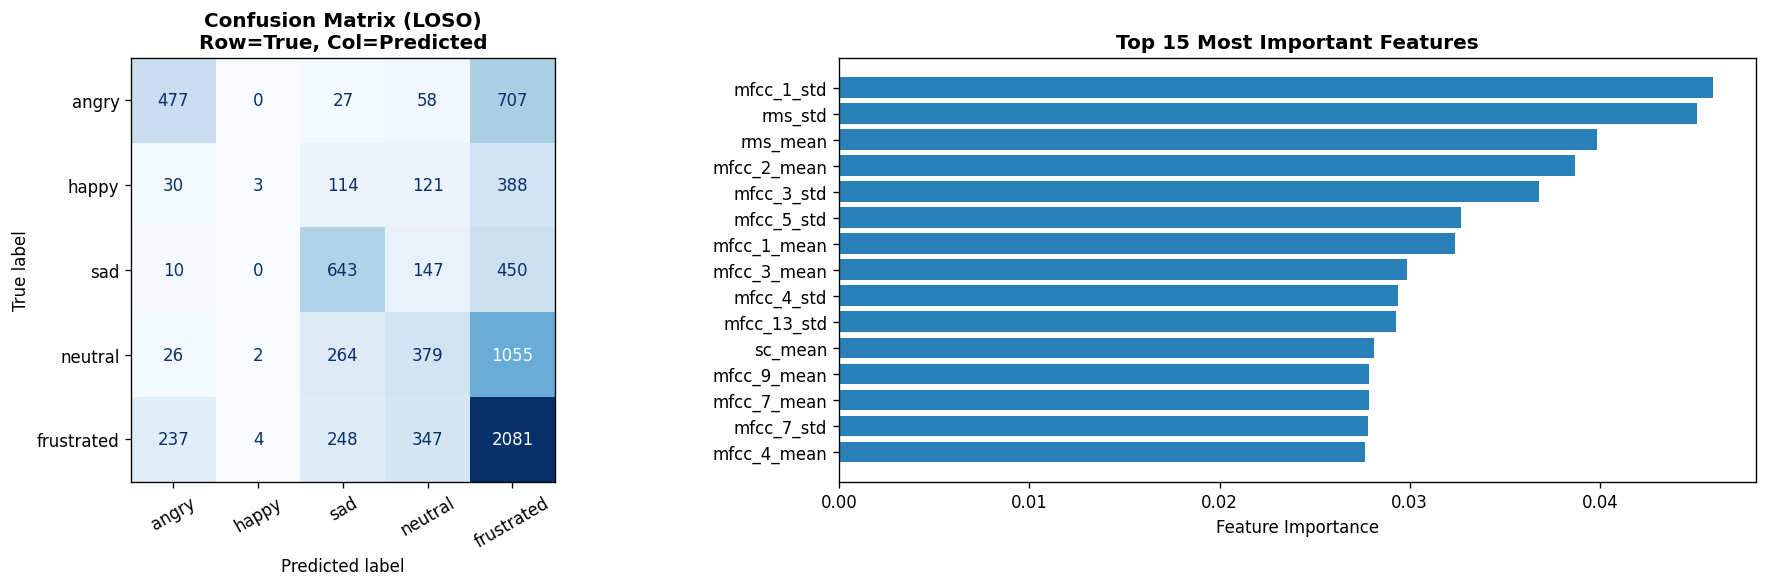


Classification Report (all LOSO folds):
              precision    recall  f1-score   support

       angry       0.61      0.38      0.47      1269
       happy       0.44      0.71      0.55      2917
         sad       0.33      0.00      0.01       656
     neutral       0.36      0.22      0.27      1726
  frustrated       0.50      0.51      0.51      1250

    accuracy                           0.46      7818
   macro avg       0.45      0.37      0.36      7818
weighted avg       0.45      0.46      0.42      7818


Most important feature: mfcc_1_std


In [11]:
cm   = confusion_matrix(all_true, all_preds, labels=TARGET_EMOTIONS)
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_EMOTIONS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix (LOSO)\nRow=True, Col=Predicted", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

clf_full = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_full.fit(X, y_emo)
importances = pd.Series(clf_full.feature_importances_, index=feature_cols)
top15 = importances.nlargest(15)
axes[1].barh(top15.index[::-1], top15.values[::-1], color="#2980b9")
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features", fontweight="bold")

plt.tight_layout()
plt.savefig(FIG_DIR/"F5_results.png", bbox_inches="tight"); plt.show()

print("\nClassification Report (all LOSO folds):")
print(classification_report(all_true, all_preds, target_names=TARGET_EMOTIONS, zero_division=0))
print(f"\nMost important feature: {importances.idxmax()}")

## 10. Per-Session UAR Plot
Visualizes performance consistency across sessions — shows if one session is a major outlier.

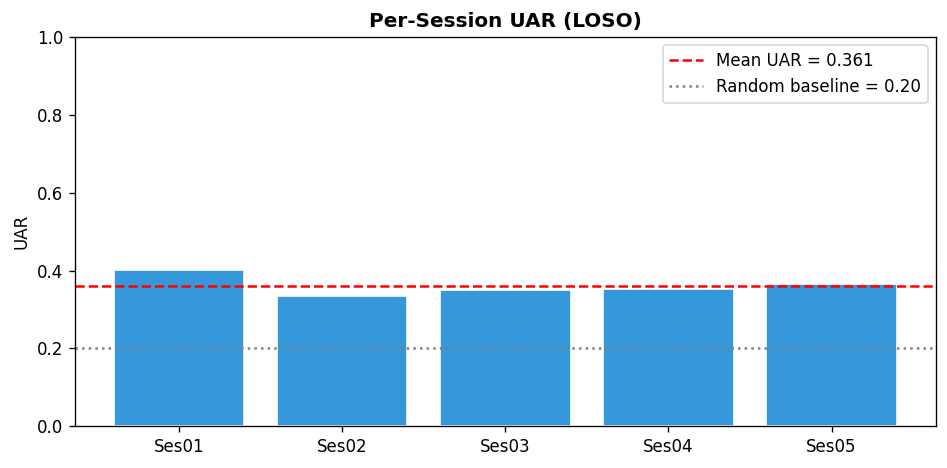

In [12]:
sess_names = [s[0] for s in session_scores]
sess_uars  = [s[1] for s in session_scores]

plt.figure(figsize=(8, 4))
plt.bar(sess_names, sess_uars, color="#3498db", edgecolor="white")
plt.axhline(mean_uar, color="red", linestyle="--", label=f"Mean UAR = {mean_uar:.3f}")
plt.axhline(0.2, color="gray", linestyle=":", label="Random baseline = 0.20")
plt.ylim(0, 1)
plt.ylabel("UAR")
plt.title("Per-Session UAR (LOSO)", fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR/"F6_per_session_uar.png", bbox_inches="tight"); plt.show()

## 11. Conclusions

1. **5-class setup**: angry, happy, sad, neutral, frustrated
2. **Feature distributions** show clear visual separation — audio carries emotion signal
3. **Random Forest LOSO UAR** beats the 5-class random baseline (0.20)
4. **Key features**: low MFCCs and RMS energy dominate feature importance

**Next Steps**
- Hyperparameter tuning (n_estimators, max_depth, class_weight)
- Additional features: spectral rolloff, chroma, tempo
- Deep learning: CNN on mel-spectrogram, HuBERT fine-tuning
- Text-audio fusion